[2026-07-27 18:34:19] [info     ] 计算因子，区间：2020-01-01 00:00:00 ~ 2024-12-31 23:59:59


[2026-07-27 18:46:35] [info     ] 读取因子库，区间：2020-01-01 00:00:00 ~ 2024-12-31 23:59:59
[2026-07-27 18:46:36] [warning  ] bigalpha_eval._latest version='v4' (use ._latest for dev only, not for prod)
[2026-07-27 18:46:48] [info     ] bigalpha_eval.v4 开始运行 ..
[2026-07-27 18:46:49] [warning  ] 未传入官方评估窗口 start_date/end_date，回退到数据自身范围（仅建议本地调试时使用）
[2026-07-27 18:46:54] [info     ] 对齐中证1000历史成分后，官方评估窗口: 2020-01-02 至 2024-12-31
[2026-07-27 18:46:54] [info     ] ========== 数据检查 ==========
[2026-07-27 18:46:54] [info     ] 通过：列名检查（date/instrument + 至少 1 个因子列） factor_cols=['factor', 'close', 'volume', 'amount', 'turn', 'change_ratio', 'daily_return', 'momentum_5', 'reversal_5', 'volatility_5', 'total_market_cap', 'float_market_cap', 'pe_ttm', 'pb', 'ps_ttm', 'sma_20', 'ema_20', 'macd_diff_12_26_9', 'macd_dea_12_26_9', 'macd_hist_12_26_9', 'rsi_12', 'kdj_k_9_3_3', 'kdj_d_9_3_3', 'bias_20', 'cci_14', 'atr_14', 'roe_avg_ttm', 'roa_avg_ttm', 'gross_profit_rate_ttm', 'net_profit_rate_ttm', 'debt_to_asset

时段,IC
2020-02-03~2020-03-31,0.0191
2024-01-15~2024-02-08,-0.0048
2024-09-24~2024-10-08,0.0718

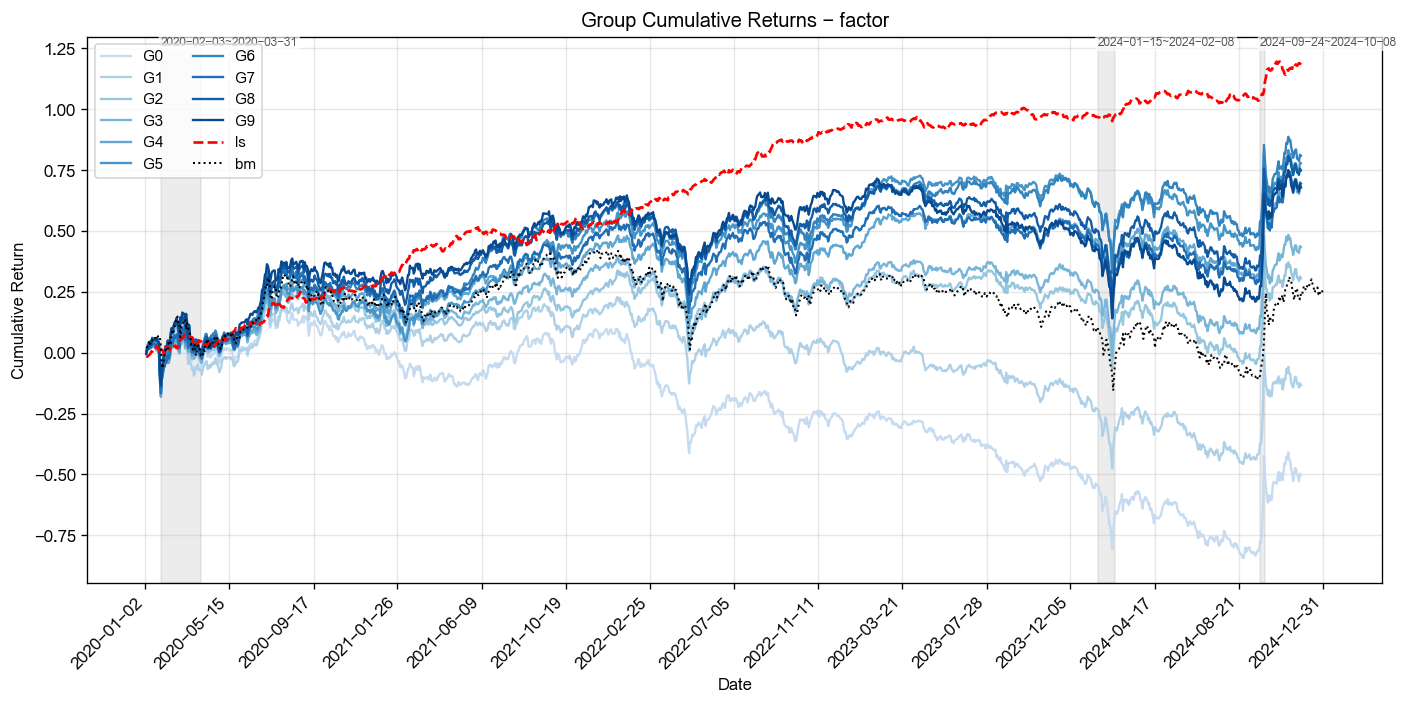
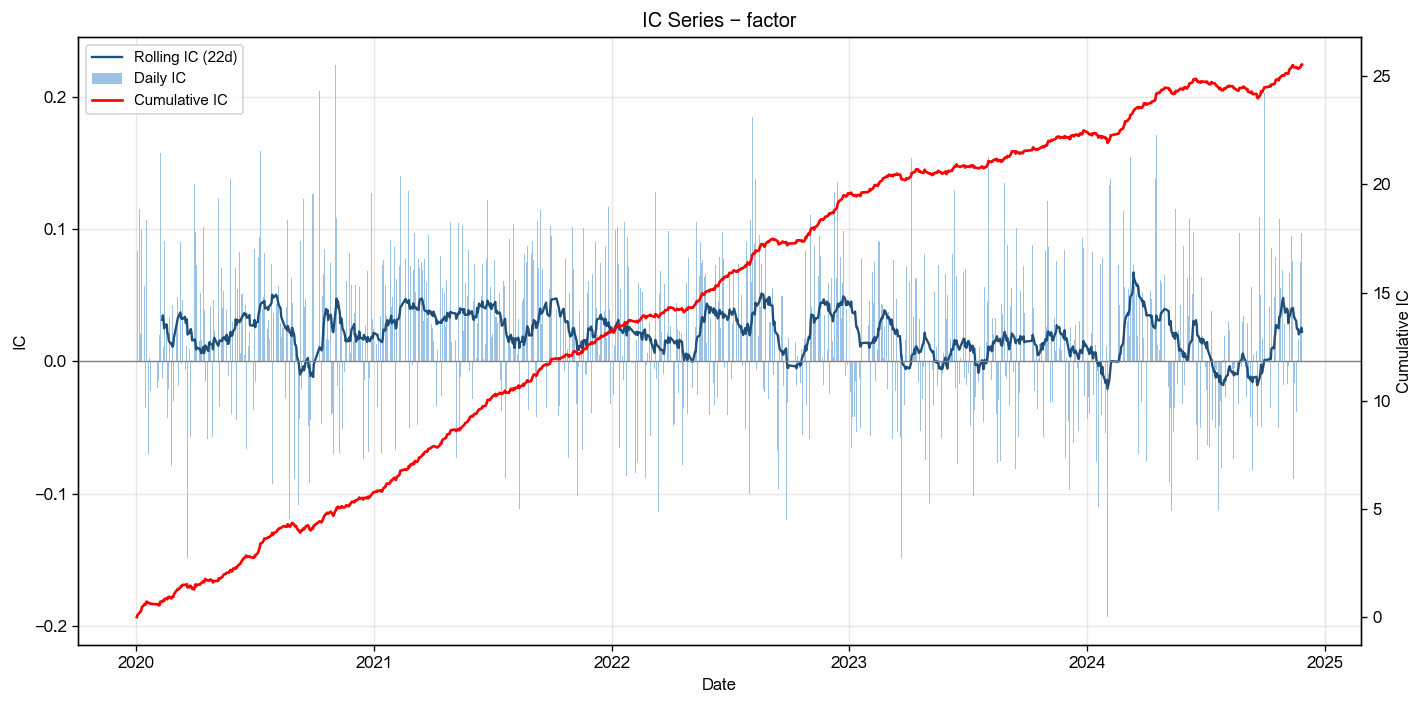
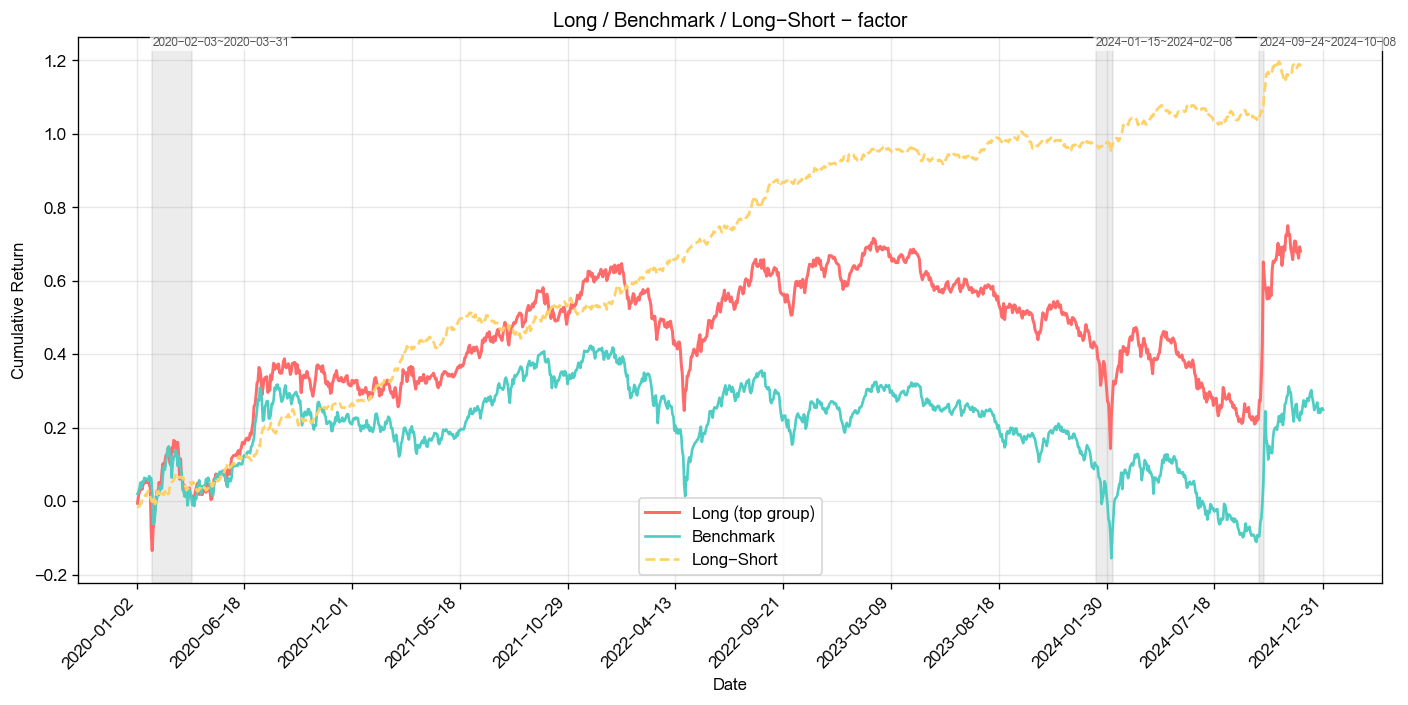
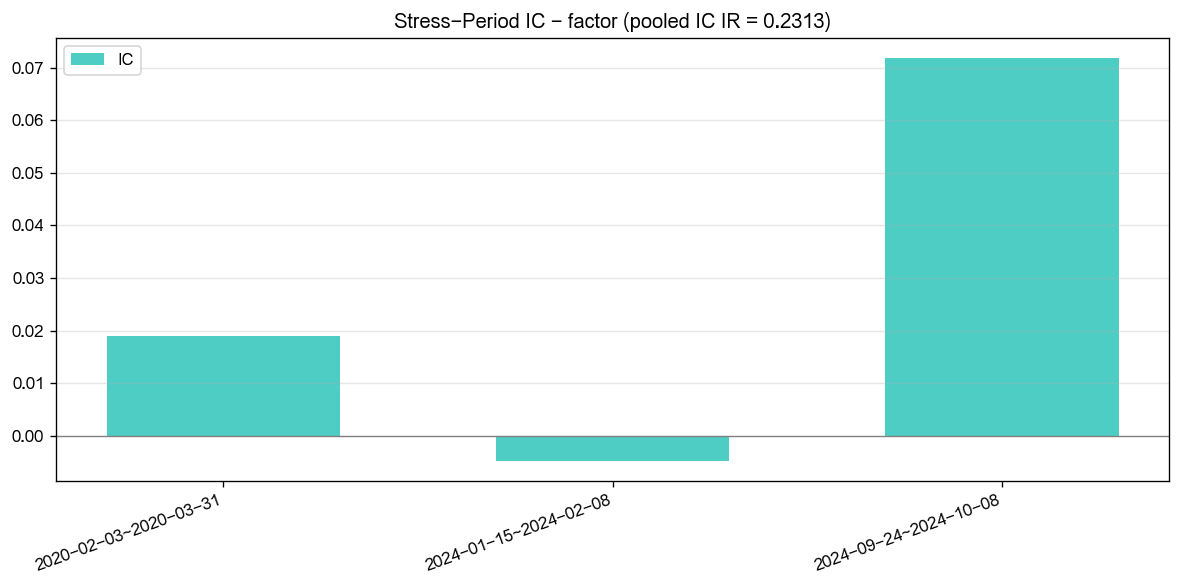
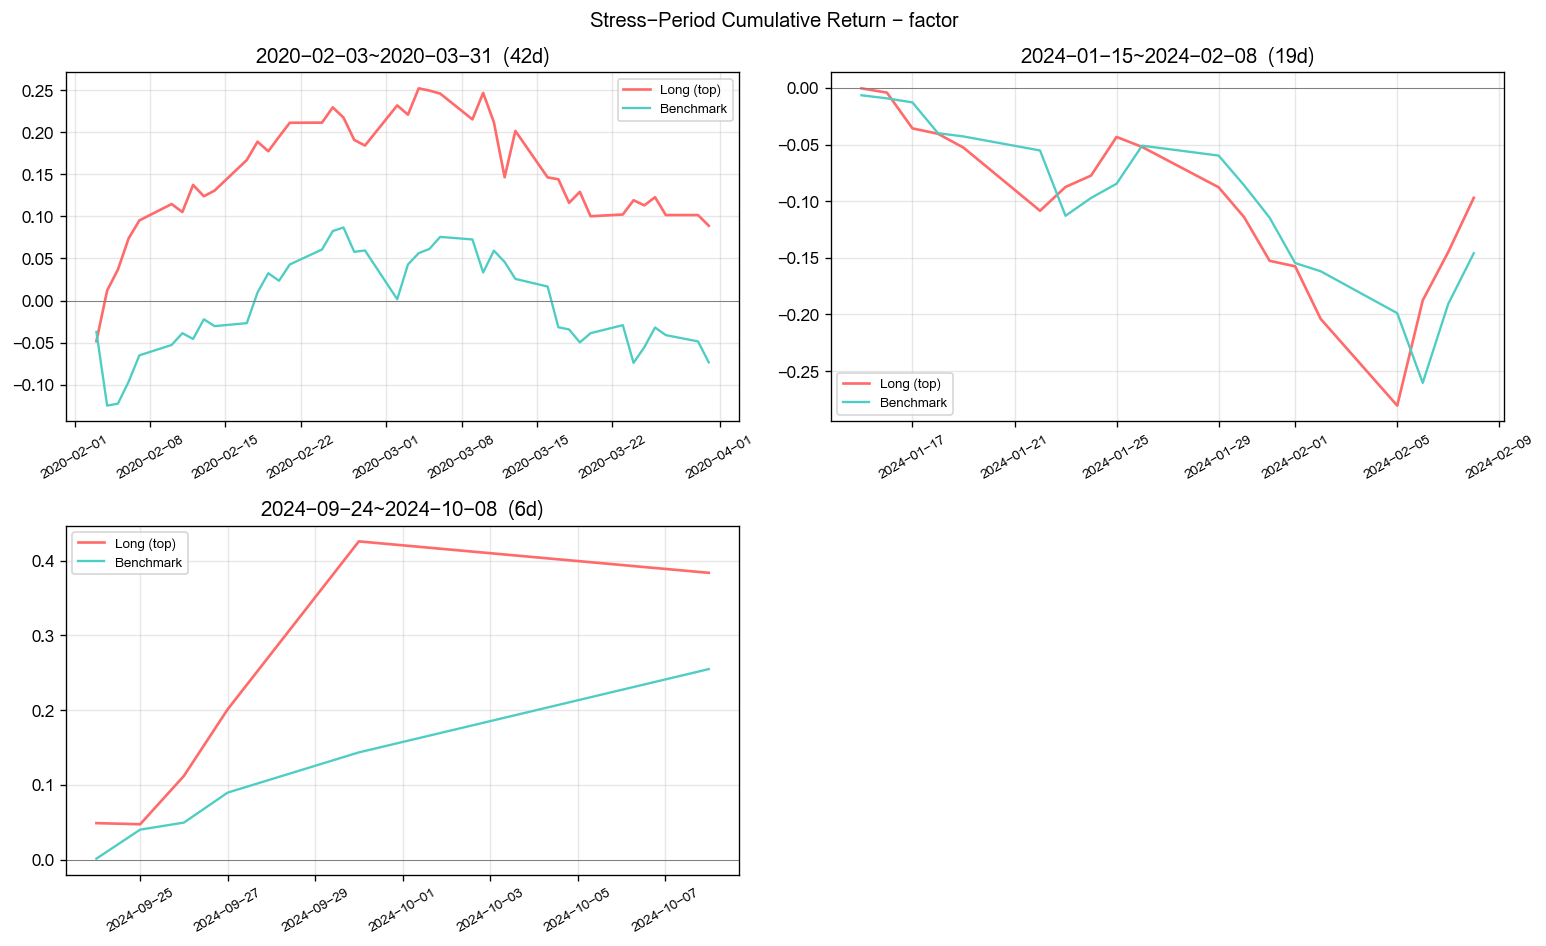

[2026-07-27 18:57:04] [info     ] ========== 因子池回归 ==========
[2026-07-27 18:57:06] [info     ] 加载 T+1 收益数据完成                  end_date=2024-12-31 instrument_count=1913 rows=2121649 start_date=2020-01-02
[2026-07-27 18:57:18] [info     ] 获取收益率数据, 耗时: 14.1201 秒
[2026-07-27 18:57:27] [info     ] 滚动 Elastic Net 拟合, 耗时: 8.7451 秒
[2026-07-27 18:57:27] [info     ] 统计 回归结果, 耗时: 0.0125 秒


#,因子名,ModelScore,mean(|w|),std(|w|),入选率
1,factor,2.2074,0.0193,0.0087,0.9828
2,beta_000300SH_22,1.5538,0.0182,0.0117,0.9828
3,momentum_5,1.4208,0.0164,0.0115,0.9138
4,volatility_5,1.4046,0.0137,0.0098,0.9483
5,turn,1.4026,0.0245,0.0175,0.8966
6,bias_20,1.3998,0.0297,0.0213,0.8966
7,net_active_buy_amount_main,1.3723,0.0180,0.0131,0.9655
8,rsi_12,1.3262,0.0324,0.0244,0.9310
9,macd_hist_12_26_9,1.3051,0.0091,0.0070,0.9483
10,gross_profit_rate_ttm,1.2635,0.0114,0.0090,0.9655

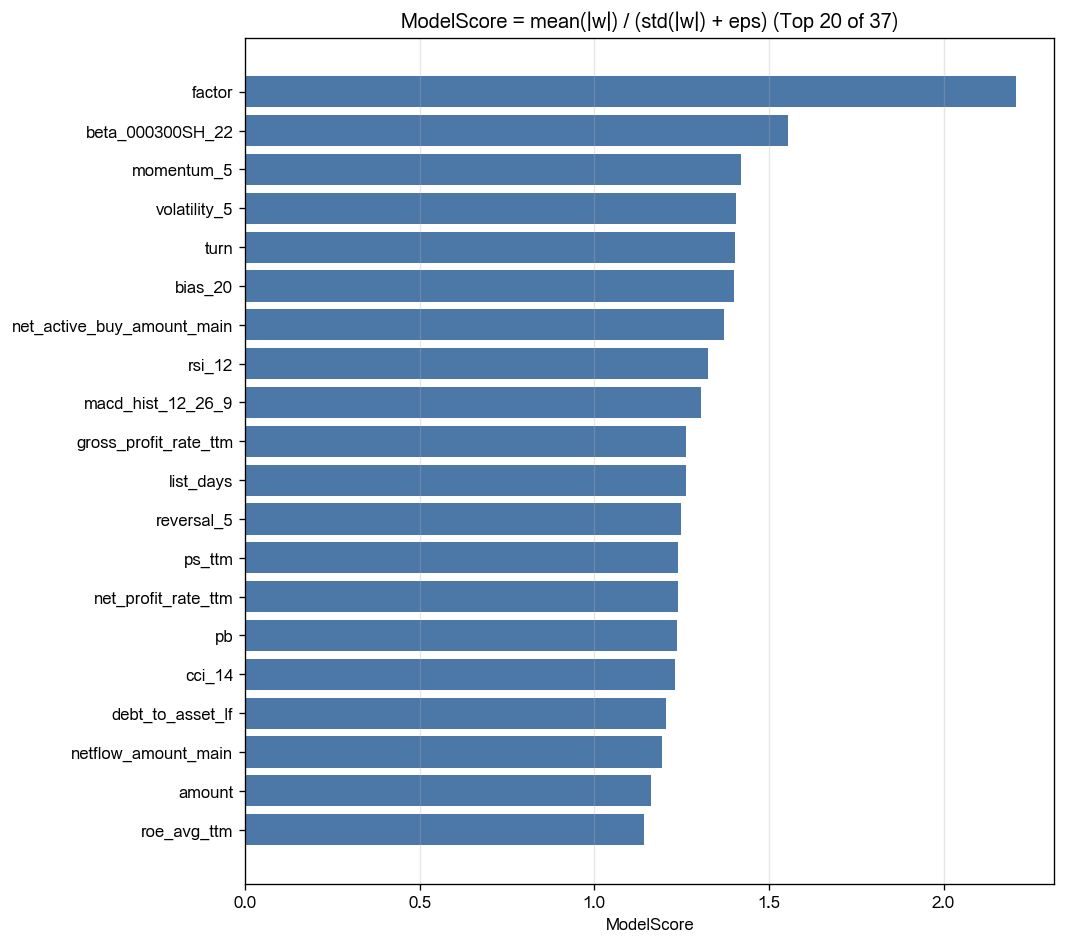
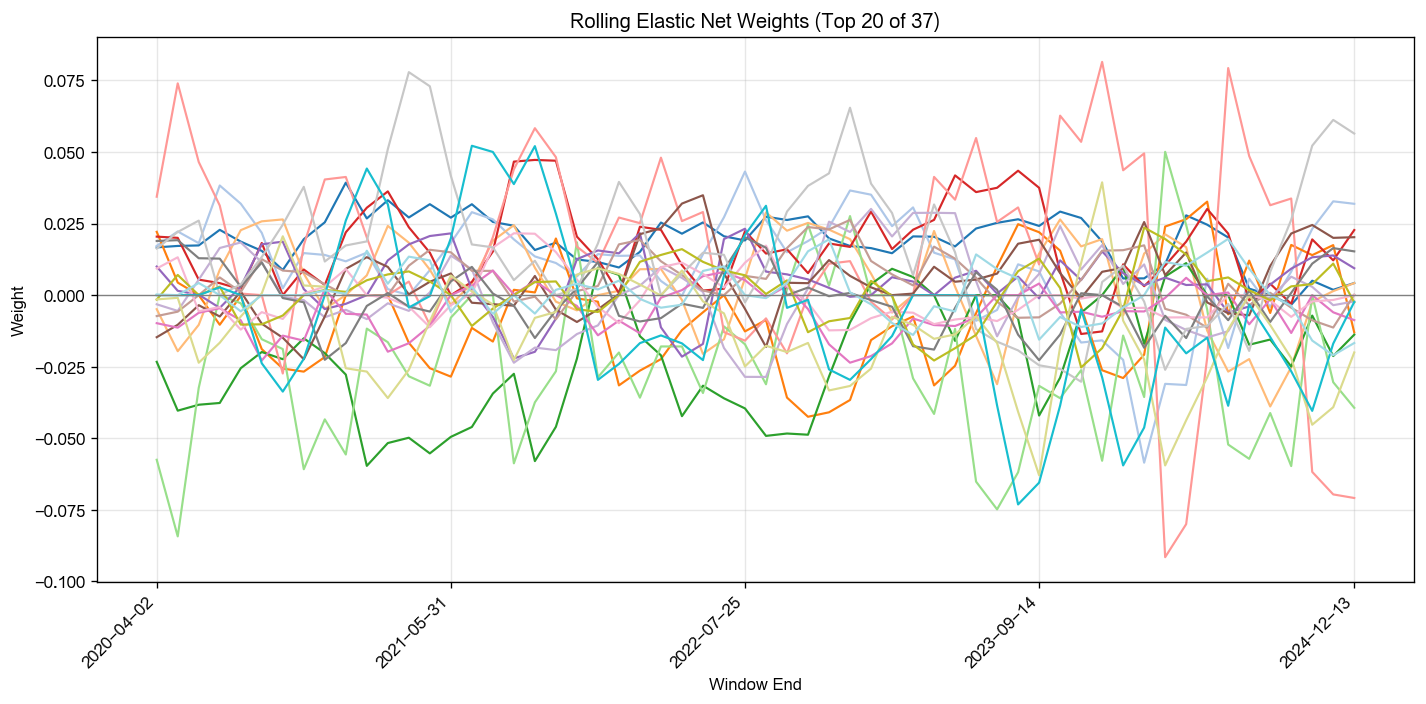
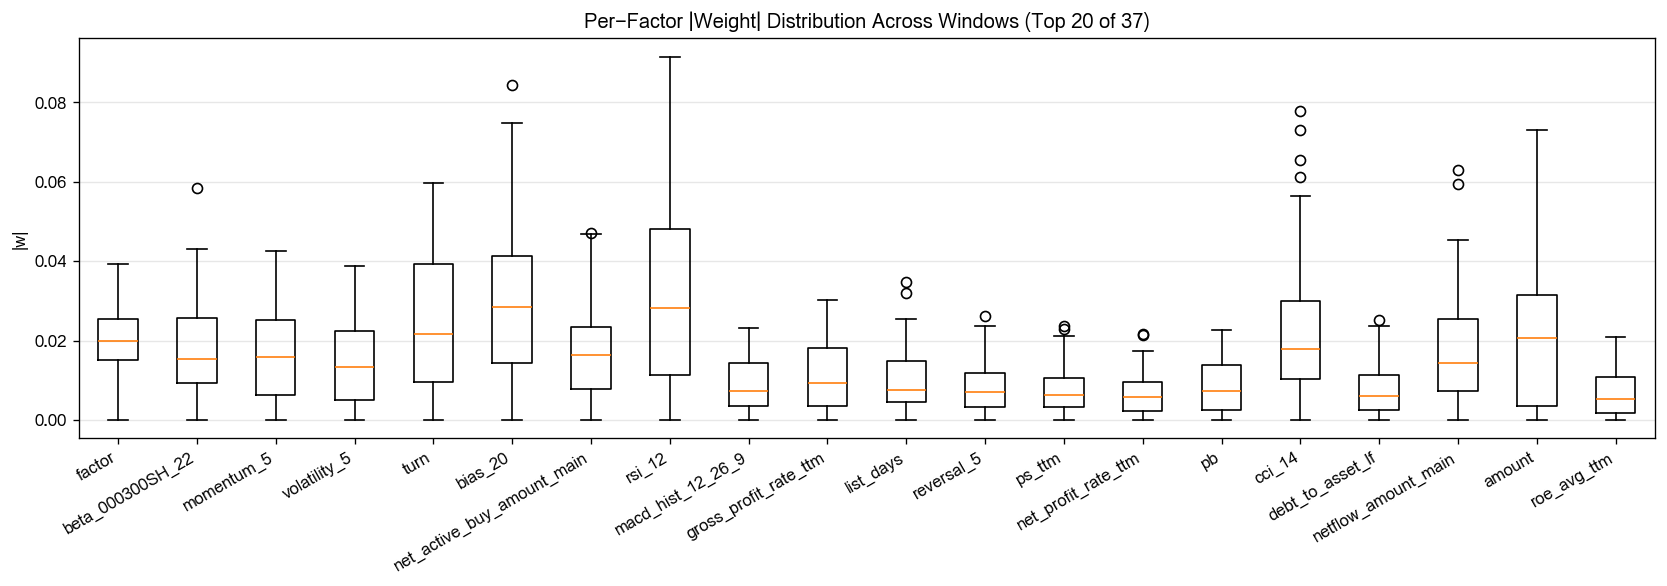
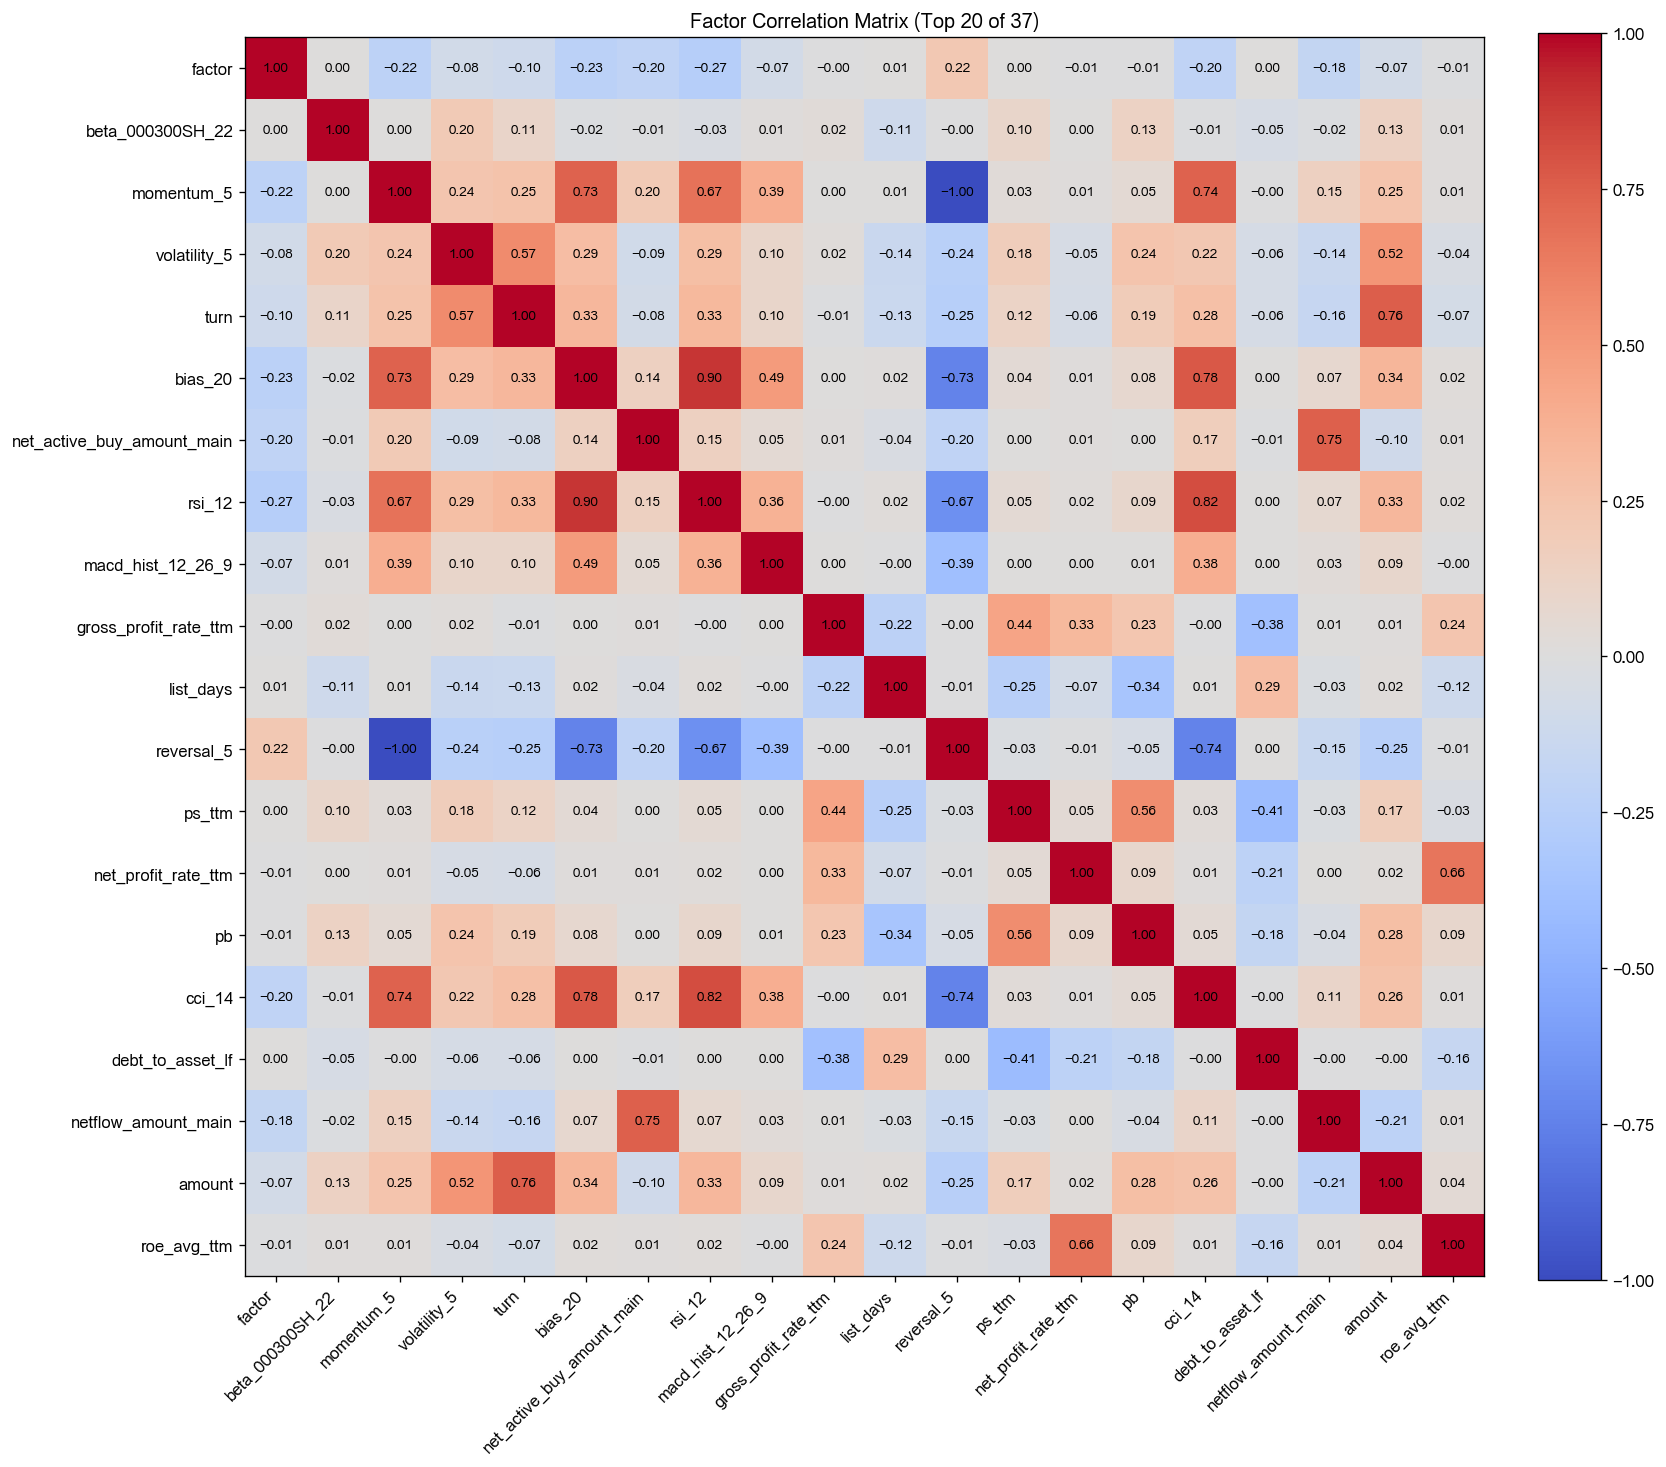

[2026-07-27 18:57:32] [warning  ] 返回的Outputs实例(size=180603292) 大于 64K, 将不会被缓存
[2026-07-27 18:57:32] [info     ] bigalpha_eval.v4 运行完成 [643.427s].


In [1]:
"""
003_RSI_MACD - 机构交易、反向RSI与MACD尾部风险增强因子

因子观测日为 T，供 T+1 日使用。

003改良因子始终完整保留。机构置信度排名低于70%时，额外加入0.2权重
的反向RSI_12；70%至90%之间RSI权重线性衰减，高于90%时不再加入RSI。
机构置信度取flow和OFI截面强度的较小值，并要求两者方向一致。标准MACD
柱仅作为尾部风险识别器：横截面最低和最高10%均被扣分，不参与方向预测。
"""

def main(datasources, start_date, end_date):
    """构建机构交易、反向RSI与MACD尾部风险增强因子。

    Parameters
    ----------
    datasources : dict
        数据源映射。本因子使用 ``datasources["bar1m"]``。
    start_date, end_date : str
        因子计算区间。

    Returns
    -------
    pandas.DataFrame
        仅包含 ``date``、``instrument``、``factor`` 三列。
    """
    import numpy as np
    import pandas as pd
    import dai

    bar1m_table = datasources["bar1m"]
    start_ts = pd.to_datetime(start_date)
    end_ts = pd.to_datetime(end_date)

    # 90个自然日用于完成MACD(12, 26, 9)预热，并减弱指数平滑
    # 初始值对回测起始阶段的影响。
    query_start_ts = start_ts.normalize() - pd.Timedelta(days=90)
    query_end_ts = end_ts.normalize() + pd.Timedelta(days=1) - pd.Timedelta(
        nanoseconds=1
    )
    chunk_days = 7
    rsi_period = 12
    macd_tail_weight = 0.2

    pool_history = dai.query(
        "SELECT date, instrument FROM bigalpha_2026_instruments",
        filters={
            "date": [
                query_start_ts,
                end_ts.normalize(),
            ]
        },
    ).df()
    pool_history["date"] = pd.to_datetime(pool_history["date"]).dt.normalize()

    instruments = pool_history["instrument"].drop_duplicates()
    instrument_sql = ", ".join(
        f"'{str(instrument).replace(chr(39), chr(39) * 2)}'"
        for instrument in instruments
    )

    sql = f"""
    SELECT
        date,
        instrument,
        pre_close,
        open AS open_price,
        high AS high_price,
        low AS low_price,
        close AS close_price,
        deal_number,
        amount,
        bid_price1,
        ask_price1,
        bid_volume1,
        ask_volume1
    FROM {bar1m_table}
    WHERE deal_number > 0
    AND amount > 0
    AND close > 0
    AND instrument IN ({instrument_sql})
    """

    stock_day = ["instrument", "trade_date"]

    def aggregate_chunk(chunk_start, chunk_end):
        """读取一批分钟数据并立即压缩为股票—日特征。"""
        bars = dai.query(
            sql,
            filters={"date": [chunk_start, chunk_end]},
        ).df()

        bars["date"] = pd.to_datetime(bars["date"])
        bars["trade_date"] = bars["date"].dt.normalize()
        bars["minute"] = bars["date"].dt.hour * 60 + bars["date"].dt.minute

        continuous_auction = (
            bars["minute"].between(9 * 60 + 30, 11 * 60 + 30)
            | bars["minute"].between(13 * 60, 15 * 60)
        )
        bars = bars.loc[continuous_auction].copy()
        bars.sort_values(["instrument", "date"], inplace=True)

        previous_close = bars.groupby(
            stock_day,
            sort=False,
        )["close_price"].shift()
        tick_direction = np.sign(bars["close_price"] - previous_close)
        tick_direction = tick_direction.fillna(
            np.sign(bars["close_price"] - bars["pre_close"])
        )

        valid_quote = (
            bars["bid_price1"].gt(0)
            & bars["ask_price1"].gt(0)
        )
        midquote = (
            bars["bid_price1"] + bars["ask_price1"]
        ).div(2).where(valid_quote)
        quote_direction = np.sign(bars["close_price"] - midquote)
        # 分钟末报价不一定是成交前报价，因此优先使用 tick rule；
        # 分钟价格不变时才使用报价方向补充。
        bars["trade_direction"] = tick_direction.where(
            tick_direction.ne(0) & tick_direction.notna(),
            quote_direction,
        ).fillna(0.0)

        # 一档盘口OFI：
        # 买一价上升视为买方新增压力，下降视为原买盘撤走；
        # 卖一价下降视为卖方新增压力，上升视为原卖盘撤走。
        previous_bid_price = bars.groupby(
            stock_day,
            sort=False,
        )["bid_price1"].shift()
        previous_ask_price = bars.groupby(
            stock_day,
            sort=False,
        )["ask_price1"].shift()
        previous_bid_volume = bars.groupby(
            stock_day,
            sort=False,
        )["bid_volume1"].shift()
        previous_ask_volume = bars.groupby(
            stock_day,
            sort=False,
        )["ask_volume1"].shift()

        valid_book = (
            bars["bid_price1"].gt(0)
            & bars["ask_price1"].gt(0)
            & bars["bid_volume1"].gt(0)
            & bars["ask_volume1"].gt(0)
            & previous_bid_price.gt(0)
            & previous_ask_price.gt(0)
            & previous_bid_volume.gt(0)
            & previous_ask_volume.gt(0)
        )
        bid_ofi = (
            bars["bid_volume1"].where(
                bars["bid_price1"].ge(previous_bid_price),
                0.0,
            )
            - previous_bid_volume.where(
                bars["bid_price1"].le(previous_bid_price),
                0.0,
            )
        )
        ask_ofi = (
            previous_ask_volume.where(
                bars["ask_price1"].ge(previous_ask_price),
                0.0,
            )
            - bars["ask_volume1"].where(
                bars["ask_price1"].le(previous_ask_price),
                0.0,
            )
        )
        bars["ofi"] = (bid_ofi + ask_ofi).where(valid_book, 0.0)
        bars["book_depth"] = (
            bars["bid_volume1"]
            + bars["ask_volume1"]
            + previous_bid_volume
            + previous_ask_volume
        ).where(valid_book, 0.0)

        bars["avg_trade_amount"] = (
            bars["amount"] / bars["deal_number"]
        )
        large_rank = bars.groupby(
            stock_day,
            sort=False,
        )["avg_trade_amount"].rank(
            method="average",
            pct=True,
        )
        bars["large_amount"] = bars["amount"].where(
            large_rank.ge(0.8),
            0.0,
        )
        bars["large_signed_amount"] = (
            bars["trade_direction"] * bars["large_amount"]
        )

        # 10:00 价格划分开盘阶段和其余交易时段。
        bars["early_close"] = bars["close_price"].where(
            bars["minute"].le(10 * 60)
        )

        return bars.groupby(
            stock_day,
            sort=False,
            as_index=False,
        ).agg(
            pre_close=("pre_close", "first"),
            open_price=("open_price", "first"),
            early_price=("early_close", "last"),
            close_price=("close_price", "last"),
            high_price=("high_price", "max"),
            low_price=("low_price", "min"),
            large_signed_amount=("large_signed_amount", "sum"),
            large_amount=("large_amount", "sum"),
            ofi=("ofi", "sum"),
            book_depth=("book_depth", "sum"),
        )

    chunk_starts = pd.date_range(
        query_start_ts,
        query_end_ts,
        freq=f"{chunk_days}D",
    )
    daily = pd.concat(
        [
            aggregate_chunk(
                chunk_start,
                min(
                    chunk_start + pd.Timedelta(days=chunk_days)
                    - pd.Timedelta(nanoseconds=1),
                    query_end_ts,
                ),
            )
            for chunk_start in chunk_starts
        ],
        ignore_index=True,
    ).sort_values(["instrument", "trade_date"])

    # 使用日收益累计重建连续复权价格，避免除权除息产生虚假RSI跳变。
    daily["daily_return"] = (
        daily["close_price"] / daily["pre_close"] - 1
    ).replace([np.inf, -np.inf], np.nan)
    daily["gross_return"] = (1 + daily["daily_return"]).where(
        daily["daily_return"].gt(-1)
    )
    daily["adjusted_close"] = daily.groupby(
        "instrument",
        sort=False,
    )["gross_return"].cumprod()

    # 标准MACD柱除以复权收盘价，消除不同股票价格量纲。MACD在本因子
    # 中只用于识别横截面极端区域，不直接作为线性方向信号。
    adjusted_close_history = daily.groupby(
        "instrument",
        sort=False,
    )["adjusted_close"]
    daily["ema12"] = adjusted_close_history.transform(
        lambda values: values.ewm(
            span=12,
            adjust=False,
            min_periods=12,
        ).mean()
    )
    daily["ema26"] = adjusted_close_history.transform(
        lambda values: values.ewm(
            span=26,
            adjust=False,
            min_periods=26,
        ).mean()
    )
    daily["dif"] = daily["ema12"] - daily["ema26"]
    daily["dea"] = daily.groupby(
        "instrument",
        sort=False,
    )["dif"].transform(
        lambda values: values.ewm(
            span=9,
            adjust=False,
            min_periods=9,
        ).mean()
    )
    daily["macd_hist_12_26_9"] = (
        (daily["dif"] - daily["dea"])
        / daily["adjusted_close"]
    ).replace([np.inf, -np.inf], np.nan)

    price_change = daily.groupby(
        "instrument",
        sort=False,
    )["adjusted_close"].diff()
    daily["gain"] = price_change.clip(lower=0.0)
    daily["loss"] = -price_change.clip(upper=0.0)
    daily["average_gain"] = daily.groupby(
        "instrument",
        sort=False,
    )["gain"].transform(
        lambda values: values.ewm(
            alpha=1 / rsi_period,
            adjust=False,
            min_periods=rsi_period,
        ).mean()
    )
    daily["average_loss"] = daily.groupby(
        "instrument",
        sort=False,
    )["loss"].transform(
        lambda values: values.ewm(
            alpha=1 / rsi_period,
            adjust=False,
            min_periods=rsi_period,
        ).mean()
    )
    relative_strength = daily["average_gain"] / daily["average_loss"]
    daily["rsi_12"] = 100 - 100 / (1 + relative_strength)

    only_gains = (
        daily["average_gain"].gt(0)
        & daily["average_loss"].eq(0)
    )
    only_losses = (
        daily["average_gain"].eq(0)
        & daily["average_loss"].gt(0)
    )
    unchanged = (
        daily["average_gain"].eq(0)
        & daily["average_loss"].eq(0)
    )
    daily.loc[only_gains, "rsi_12"] = 100.0
    daily.loc[only_losses, "rsi_12"] = 0.0
    daily.loc[unchanged, "rsi_12"] = 50.0

    daily["large_flow"] = (
        daily["large_signed_amount"] / daily["large_amount"]
    ).replace([np.inf, -np.inf], np.nan)
    daily["ofi_ratio"] = (
        daily["ofi"] / daily["book_depth"]
    ).replace([np.inf, -np.inf], np.nan)

    flow_history = daily.groupby(
        "instrument",
        sort=False,
    )["large_flow"]
    daily["flow_mean10"] = flow_history.transform(
        lambda values: values.shift(1).rolling(
            10,
            min_periods=5,
        ).mean()
    )
    daily["flow_std10"] = flow_history.transform(
        lambda values: values.shift(1).rolling(
            10,
            min_periods=5,
        ).std()
    )
    flow_scale = daily["flow_std10"].where(
        daily["flow_std10"].gt(1e-8),
        1.0,
    )
    daily["flow_z"] = (
        daily["large_flow"] - daily["flow_mean10"]
    ) / flow_scale

    ofi_history = daily.groupby(
        "instrument",
        sort=False,
    )["ofi_ratio"]
    daily["ofi_mean10"] = ofi_history.transform(
        lambda values: values.shift(1).rolling(
            10,
            min_periods=5,
        ).mean()
    )
    daily["ofi_std10"] = ofi_history.transform(
        lambda values: values.shift(1).rolling(
            10,
            min_periods=5,
        ).std()
    )
    ofi_scale = daily["ofi_std10"].where(
        daily["ofi_std10"].gt(1e-8),
        1.0,
    )
    daily["ofi_z"] = (
        daily["ofi_ratio"] - daily["ofi_mean10"]
    ) / ofi_scale

    daily["early_return"] = (
        daily["early_price"] / daily["open_price"] - 1
    )
    daily["late_return"] = (
        daily["close_price"] / daily["early_price"] - 1
    )
    daily["close_location"] = (
        (daily["close_price"] - daily["low_price"])
        / (daily["high_price"] - daily["low_price"])
    ).replace([np.inf, -np.inf], np.nan)

    # 连续形态分数：开盘先跌后涨为正，先涨后跌为负；
    # 收盘在日内区间中的位置用于加强方向确认。
    daily["intraday_range"] = (
        (daily["high_price"] - daily["low_price"])
        / daily["open_price"]
    )
    daily["shape_raw"] = (
        daily["late_return"]
        - daily["early_return"]
        + (2 * daily["close_location"] - 1)
        * daily["intraday_range"]
    )

    signals = daily.rename(columns={"trade_date": "date"})[
        [
            "date",
            "instrument",
            "flow_z",
            "ofi_z",
            "shape_raw",
            "rsi_12",
            "macd_hist_12_26_9",
        ]
    ]

    stock_pool = pool_history.loc[
        pool_history["date"].between(
            start_ts.normalize(),
            end_ts.normalize(),
        ),
        ["date", "instrument"],
    ]
    factor = stock_pool.merge(
        signals,
        how="left",
        on=["date", "instrument"],
    )

    # 各项均转换为 [-0.5, 0.5] 的截面分数。
    # 同向时自然叠加，反向时自然抵消，不再使用稀疏的硬过滤。
    flow_rank = factor.groupby(
        "date",
        sort=False,
    )["flow_z"].rank(
        method="average",
        pct=True,
    )
    shape_rank = factor.groupby(
        "date",
        sort=False,
    )["shape_raw"].rank(
        method="average",
        pct=True,
    )
    ofi_rank = factor.groupby(
        "date",
        sort=False,
    )["ofi_z"].rank(
        method="average",
        pct=True,
    )
    rsi_rank = factor.groupby(
        "date",
        sort=False,
    )["rsi_12"].rank(
        method="average",
        pct=True,
    )
    macd_rank = factor.groupby(
        "date",
        sort=False,
    )["macd_hist_12_26_9"].rank(
        method="average",
        pct=True,
    )
    # 用当日排名均值居中；比直接减0.5更适合有限股票数量和并列值。
    factor["flow_alpha"] = flow_rank - flow_rank.groupby(
        factor["date"]
    ).transform("mean")
    factor["shape_alpha"] = -1 * (shape_rank - shape_rank.groupby(
        factor["date"]
    ).transform("mean"))
    factor["ofi_alpha"] = ofi_rank - ofi_rank.groupby(
        factor["date"]
    ).transform("mean")
    factor["rsi_alpha"] = rsi_rank - rsi_rank.groupby(
        factor["date"]
    ).transform("mean")
    factor["enhanced_flow_alpha"] = (
        0.5 * factor["flow_alpha"]
        + 0.5 * factor["ofi_alpha"]
    )
    factor["factor_003"] = (
        0.2 * factor["enhanced_flow_alpha"]
        + 0.8 * factor["shape_alpha"]
    )

    # 只有flow与OFI方向一致时才视为存在机构型交易证据；
    # 两项强度的较小值决定置信度，防止单项异常触发。
    institution_agreement = (
        factor["flow_alpha"] * factor["ofi_alpha"]
    ).gt(0)
    factor["institution_strength"] = np.minimum(
        factor["flow_alpha"].abs(),
        factor["ofi_alpha"].abs(),
    ).where(
        institution_agreement,
        0.0,
    )
    factor["institution_strength_rank"] = factor.groupby(
        "date",
        sort=False,
    )["institution_strength"].rank(
        method="average",
        pct=True,
    )

    # 置信度排名低于70%时RSI增强权重为0.2，高于90%时为0；
    # 中间区间线性衰减。003在全部股票上始终完整保留。
    factor["institution_gate"] = (
        (factor["institution_strength_rank"] - 0.7) / 0.2
    ).clip(
        lower=0.0,
        upper=1.0,
    ).where(
        institution_agreement,
        0.0,
    )
    factor["rsi_weight"] = 0.2 * (
        1 - factor["institution_gate"]
    )
    factor["factor_003_rsi"] = (
        factor["factor_003"]
        + factor["rsi_weight"]
        * (-factor["rsi_alpha"])
    )

    # MACD不承担趋势方向预测，只识别横截面两端10%的风险。进入尾部
    # 越深，风险强度由0线性增加到1；中间80%的股票不受直接惩罚。
    lower_tail_risk = (
        (0.10 - macd_rank) / 0.10
    ).clip(
        lower=0.0,
        upper=1.0,
    )
    upper_tail_risk = (
        (macd_rank - 0.90) / 0.10
    ).clip(
        lower=0.0,
        upper=1.0,
    )
    factor["macd_tail_risk"] = (
        lower_tail_risk + upper_tail_risk
    )

    # 风险项按日居中：尾部股票得到负向调整，非尾部股票仅获得用于
    # 保持截面均值为0的微小正向补偿。最大风险扣分权重为0.2。
    factor["macd_risk_alpha"] = -(
        factor["macd_tail_risk"]
        - factor.groupby(
            "date",
            sort=False,
        )["macd_tail_risk"].transform("mean")
    )
    factor["factor_linear"] = (
        factor["factor_003_rsi"]
        + macd_tail_weight * factor["macd_risk_alpha"]
    )

    # 线性组合的分组收益呈非单调结构：70%分位附近表现最好，最高
    # 分位仍为正收益，而最低30%为负收益。因此不再直接输出线性
    # 组合，而是先转换为每日横截面分位，再进行非对称连续校准。
    combined_rank = factor.groupby(
        "date",
        sort=False,
    )["factor_linear"].rank(
        method="average",
        pct=True,
    )

    # 分段函数保持连续：
    #   [0%, 30%]  ：由-1线性升至0，识别明确的负收益尾部；
    #   (30%, 70%] ：由0线性升至1，对应收益持续改善的区间；
    #   (70%, 100%]：由1缓慢降至0.5，70%附近最优，但最高组仍为正。
    factor["factor_signal_raw"] = np.select(
        [
            combined_rank.lt(0.30),
            combined_rank.le(0.70),
        ],
        [
            combined_rank / 0.30 - 1,
            (combined_rank - 0.30) / 0.40,
        ],
        default=(
            1
            - 0.5 * (combined_rank - 0.70) / 0.30
        ),
    )
    factor["factor_signal_raw"] = factor[
        "factor_signal_raw"
    ].where(
        combined_rank.notna()
    )

    # 按日居中，不改变上述非线性排序，同时保持不同交易日的信号
    # 水平可比；缺失值最终回填为0，保证股票池覆盖。
    factor["factor"] = (
        factor["factor_signal_raw"]
        - factor.groupby(
            "date",
            sort=False,
        )["factor_signal_raw"].transform("mean")
    ).fillna(0.0)

    result = (
        factor[["date", "instrument", "factor"]]
        .sort_values(["date", "instrument"])
        .reset_index(drop=True)
    )

    return result


if __name__ == '__main__':
    from bigmodule import M
    import dai
    import structlog

    logger = structlog.get_logger()

    # 本地自测时自行构造数据源映射（评测时由平台注入，逻辑名固定为 "bar1m"/"financial"）
    datasources = {'financial': 'bigalpha_2026_financial', 'bar1m': 'bigalpha_2026_stock_bar1m'}
    start_date = '2020-01-01 00:00:00'
    end_date = '2024-12-31 23:59:59'

    # 计算因子
    logger.info(f"计算因子，区间：{start_date} ~ {end_date}")
    factor_data = main(datasources, start_date, end_date)

    # 读取平台因子库用于回归评估，您可以换成自己的因子库
    logger.info(f"读取因子库，区间：{start_date} ~ {end_date}")
    factor_pool = dai.query(
        "SELECT * FROM bigalpha_2026_factorlib",
        filters={'date': [start_date, end_date]},
    ).df()

    # 评估系统：
    # process_pools=False 表示不对因子库再做预处理（bigalpha_2026_factorlib 已处理过）
    # show=True 表示画出评估图表
    result = M.bigalpha_eval._latest(
        factor_data=factor_data,
        factor_pool=factor_pool,
        process_pools=False,
        show=True,
    )
